# EDA 14 - Price, COGS, Gross Profit, and Gross Margin Analysis

This notebook analyzes price, COGS, gross profit, and gross margin by product, category, and segment using `products.csv`, `order_items.csv`, and `sales.csv`, with optional order dates from `orders.csv`.

## 1. Setup and file discovery

Locate required and optional CSV files recursively from the current working directory. All tables and charts are displayed directly in the notebook.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 280)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
REQUIRED_FILES = ["products.csv", "order_items.csv", "sales.csv"]
OPTIONAL_FILES = ["orders.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

warning_messages = []
loaded_files = {}
file_paths = {}
analysis_ready = False
margin_available = False
date_available = False
sales_daily_available = False

financial_items = pd.DataFrame()
category_summary = pd.DataFrame()
segment_summary = pd.DataFrame()
quadrant_df = pd.DataFrame()
distribution_checks_df = pd.DataFrame()
monthly_financial = pd.DataFrame()
feature_preview = pd.DataFrame()

premium_margin_statement = "Not evaluated."
revenue_margin_statement = "Not evaluated."
margin_trend_statement = "Not evaluated."
forecast_feature_warning = "Future COGS, future margin, and future product mix must not be used directly for forecasting unless separately forecasted."
recommended_margin_features = [
    "historical_margin_lag",
    "cogs_lag",
    "cogs_roll_mean",
    "margin_ratio_lag",
    "margin_ratio_roll_mean",
    "gross_profit_lag",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in ALL_FILES:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": filename in REQUIRED_FILES,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in ALL_FILES
])

missing_required = [filename for filename in REQUIRED_FILES if file_paths[filename] is None]
if missing_required:
    warning_messages.append("Required files not found: " + ", ".join(missing_required))
if file_paths.get("orders.csv") is None:
    warning_messages.append("Optional orders.csv was not found; monthly item-level margin analysis may be unavailable.")

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,products.csv,True,True,datathon-2026-round-1\products.csv,1
1,order_items.csv,True,True,datathon-2026-round-1\order_items.csv,1
2,sales.csv,True,True,datathon-2026-round-1\sales.csv,1
3,orders.csv,False,True,datathon-2026-round-1\orders.csv,1


## 2. Load products, order_items, sales, and optional orders

Load all available files safely with pandas. Missing required files are reported clearly; missing optional files do not stop the rest of the notebook.

In [2]:
load_rows = []
for filename in ALL_FILES:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file not found"})
        continue
    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        loaded_files[filename] = None
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in ALL_FILES:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,required,loaded,rows,columns,error
0,products.csv,True,True,2412,8,
1,order_items.csv,True,True,714669,7,
2,sales.csv,True,True,3833,3,
3,orders.csv,False,True,646945,8,


Preview: products.csv


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


Preview: order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


Preview: sales.csv


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


Preview: orders.csv


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


## 3. Identify key, category, segment, price, COGS, revenue, and date columns

Infer product and order keys, product descriptors, financial fields, and date fields. The notebook can infer item revenue as price times quantity minus discount and item COGS as product unit cost times quantity.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    name_points = 0
    if name in {"date", "order_date", "created_at", "timestamp", "transaction_date", "sales_date"}:
        name_points += 5
    elif "date" in name_tokens or "date" in name or "timestamp" in name or "time" in name:
        name_points += 3
    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {"column": column_name, "date_score": -5.0, "date_parse_success": 0.0, "plausible_date_share": 0.0}
    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parse_success = float(parsed[mask].notna().mean()) if non_empty else 0.0
    parsed_valid = parsed[mask].dropna()
    if len(parsed_valid):
        plausible_share = float(parsed_valid.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31")).mean())
        unique_dates = int(parsed_valid.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0
    score = name_points + 3 * parse_success + 2 * plausible_share + min(unique_dates / 20, 1)
    return {"column": column_name, "date_score": round(score, 4), "date_parse_success": round(parse_success, 4), "plausible_date_share": round(plausible_share, 4)}


def choose_date_column(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    candidates = pd.DataFrame([date_score(col, df[col]) for col in df.columns])
    candidates = candidates.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def string_key_values(series):
    return series.dropna().astype("string").str.strip()


def key_candidates(df, key_kind):
    if df is None or df.empty:
        return []
    candidates = []
    for col in df.columns:
        name = normalize_name(col)
        name_tokens = set(name.split("_"))
        score = 0
        if key_kind == "product":
            if name in {"product_id", "productid", "sku", "item_id"}:
                score += 8
            if "product" in name_tokens or "product" in name or "sku" in name:
                score += 4
        if key_kind == "order":
            if name in {"order_id", "orderid", "id_order"}:
                score += 8
            if "order" in name_tokens or "order" in name:
                score += 4
        if "id" in name_tokens or name.endswith("_id") or name == "id":
            score += 3
        if "date" in name or "time" in name:
            score -= 5
        if score > 0:
            candidates.append((col, score))
    if not candidates:
        for col in df.columns:
            if df[col].nunique(dropna=True) > 1:
                candidates.append((col, 0))
    return candidates


def choose_join_key(left_df, right_df, key_kind):
    rows = []
    for left_col, left_score in key_candidates(left_df, key_kind):
        left_values = set(string_key_values(left_df[left_col]).unique())
        for right_col, right_score in key_candidates(right_df, key_kind):
            right_values = set(string_key_values(right_df[right_col]).unique())
            overlap_rate = len(left_values & right_values) / max(1, len(left_values)) if left_values and right_values else 0.0
            score = left_score + right_score + 10 * overlap_rate
            rows.append({
                "left_column": left_col,
                "right_column": right_col,
                "key_kind": key_kind,
                "score": score,
                "left_unique": len(left_values),
                "right_unique": len(right_values),
                "left_unique_overlap_rate": overlap_rate,
            })
    candidates = pd.DataFrame(rows).sort_values(["score", "left_unique_overlap_rate"], ascending=False) if rows else pd.DataFrame()
    if candidates.empty:
        return None, None, candidates
    best = candidates.iloc[0]
    if best["left_unique_overlap_rate"] < 0.05 and best["score"] < 8:
        return None, None, candidates
    return best["left_column"], best["right_column"], candidates


def choose_text_column(df, positive_terms, negative_terms=None, exact_terms=None, max_unique_rate=None):
    negative_terms = negative_terms or []
    exact_terms = exact_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = df[col]
        non_null = values.notna().sum()
        unique = values.nunique(dropna=True)
        unique_rate = unique / max(non_null, 1)
        score = 0
        if name in exact_terms:
            score += 10
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 4
        if pd.api.types.is_object_dtype(values) or pd.api.types.is_string_dtype(values):
            score += 2
        if max_unique_rate is not None and unique_rate > max_unique_rate:
            score -= 3
        if 2 <= unique <= 200:
            score += 1
        rows.append({"column": col, "score": score, "unique_values": unique, "unique_rate": unique_rate})
    candidates = pd.DataFrame(rows).sort_values(["score", "unique_values"], ascending=[False, True])
    if candidates.empty or candidates.iloc[0]["score"] <= 0:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


def choose_numeric_by_terms(df, positive_terms, negative_terms=None):
    negative_terms = negative_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = numeric_series(df[col])
        non_empty = max(int(non_empty_mask(df[col]).sum()), 1)
        numeric_success = values.notna().sum() / non_empty
        if numeric_success < 0.70:
            continue
        score = numeric_success
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 5
        if values.dropna().std(ddof=1) > 0:
            score += 1
        rows.append({"column": col, "score": score, "numeric_parse_success": numeric_success, "mean": values.mean(), "std": values.std(ddof=1)})
    candidates = pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()
    if candidates.empty or candidates.iloc[0]["score"] <= 1:
        return None, candidates
    return candidates.iloc[0]["column"], candidates


products = loaded_files.get("products.csv")
order_items = loaded_files.get("order_items.csv")
sales = loaded_files.get("sales.csv")
orders = loaded_files.get("orders.csv")

if products is None or order_items is None:
    product_id_items_col = product_id_products_col = None
    order_id_items_col = order_id_orders_col = None
    order_date_col = None
    product_name_col = category_col = segment_col = None
    quantity_col = item_price_col = discount_col = direct_revenue_col = item_cogs_col = product_cogs_col = product_price_col = profit_col = margin_col = None
    revenue_method = "not available"
    detection_summary_df = pd.DataFrame([{"warning": "products.csv or order_items.csv was not loaded."}])
else:
    product_id_items_col, product_id_products_col, product_key_candidates_df = choose_join_key(order_items, products, "product")
    if orders is not None:
        order_id_items_col, order_id_orders_col, order_key_candidates_df = choose_join_key(order_items, orders, "order")
        order_date_col, order_date_candidates_df = choose_date_column(orders)
    else:
        order_id_items_col = order_id_orders_col = order_date_col = None
        order_key_candidates_df = order_date_candidates_df = pd.DataFrame()

    product_name_col, product_name_candidates_df = choose_text_column(products, ["product_name", "name", "title"], ["id", "date", "price", "cost"], exact_terms=["product_name"], max_unique_rate=None)
    category_col, category_candidates_df = choose_text_column(products, ["category", "department", "class"], ["id", "date", "price", "cost"], exact_terms=["category"], max_unique_rate=0.75)
    segment_col, segment_candidates_df = choose_text_column(products, ["segment", "tier", "group"], ["id", "date", "price", "cost"], exact_terms=["segment"], max_unique_rate=0.75)

    quantity_col, quantity_candidates_df = choose_numeric_by_terms(order_items, ["quantity", "qty", "units"], ["price", "discount", "amount", "id"])
    item_price_col, item_price_candidates_df = choose_numeric_by_terms(order_items, ["unit_price", "price", "selling_price", "sales_price"], ["discount", "quantity", "qty", "id"])
    discount_col, discount_candidates_df = choose_numeric_by_terms(order_items, ["discount"], ["id", "date"])
    direct_revenue_col, direct_revenue_candidates_df = choose_numeric_by_terms(order_items, ["revenue", "line_total", "item_total", "sales_amount", "net_sales", "subtotal", "line_subtotal", "total"], ["discount", "price", "cost", "cogs", "quantity", "qty", "id"])
    item_cogs_col, item_cogs_candidates_df = choose_numeric_by_terms(order_items, ["cogs", "cost", "unit_cost"], ["price", "discount", "quantity", "id"])
    product_cogs_col, product_cogs_candidates_df = choose_numeric_by_terms(products, ["cogs", "cost", "unit_cost"], ["price", "id"])
    product_price_col, product_price_candidates_df = choose_numeric_by_terms(products, ["price", "unit_price", "selling_price"], ["cost", "cogs", "id"])
    profit_col, profit_candidates_df = choose_numeric_by_terms(order_items, ["gross_profit", "profit"], ["id", "margin"])
    margin_col, margin_candidates_df = choose_numeric_by_terms(order_items, ["gross_margin", "margin"], ["id"])

    if direct_revenue_col is not None and any(term in normalize_name(direct_revenue_col) for term in ["discount", "price", "cost", "cogs", "quantity", "qty", "id"]):
        direct_revenue_col = None
    if item_cogs_col is not None and not any(term in normalize_name(item_cogs_col) for term in ["cogs", "cost"]):
        item_cogs_col = None
    if profit_col is not None and "profit" not in normalize_name(profit_col):
        profit_col = None
    if margin_col is not None and "margin" not in normalize_name(margin_col):
        margin_col = None

    if direct_revenue_col is not None:
        revenue_method = f"direct item revenue column: {direct_revenue_col}"
    elif quantity_col is not None and item_price_col is not None:
        revenue_method = f"inferred: {quantity_col} * {item_price_col} (unit price is post-discount)"
    else:
        revenue_method = "not available"

    detection_summary_df = pd.DataFrame([{
        "product_id_in_order_items": product_id_items_col,
        "product_id_in_products": product_id_products_col,
        "order_id_in_order_items": order_id_items_col,
        "order_id_in_orders": order_id_orders_col,
        "order_date_column": order_date_col,
        "product_name_column": product_name_col,
        "category_column": category_col,
        "segment_column": segment_col,
        "quantity_column": quantity_col,
        "item_price_column": item_price_col,
        "product_price_column": product_price_col,
        "discount_column": discount_col,
        "direct_revenue_column": direct_revenue_col,
        "item_cogs_column": item_cogs_col,
        "product_cogs_column": product_cogs_col,
        "profit_column": profit_col,
        "margin_column": margin_col,
        "revenue_method": revenue_method,
    }])

sales_date_col = sales_revenue_col = sales_cogs_col = None
if sales is not None and not sales.empty:
    sales_date_col, sales_date_candidates_df = choose_date_column(sales)
    sales_revenue_col, sales_revenue_candidates_df = choose_numeric_by_terms(sales, ["revenue", "sales", "amount", "total"], ["cogs", "cost", "id"])
    sales_cogs_col, sales_cogs_candidates_df = choose_numeric_by_terms(sales, ["cogs", "cost"], ["revenue", "sales", "id"])
else:
    sales_date_candidates_df = sales_revenue_candidates_df = sales_cogs_candidates_df = pd.DataFrame()

display(detection_summary_df)
display(pd.DataFrame([{
    "sales_date_column": sales_date_col,
    "sales_revenue_column": sales_revenue_col,
    "sales_cogs_column": sales_cogs_col,
    "sales_daily_margin_supported": bool(sales_date_col and sales_revenue_col and sales_cogs_col),
}]))

for label, df in [
    ("Product key candidates", locals().get("product_key_candidates_df", pd.DataFrame())),
    ("Order key candidates", locals().get("order_key_candidates_df", pd.DataFrame())),
    ("Order date candidates", locals().get("order_date_candidates_df", pd.DataFrame())),
    ("Category candidates", locals().get("category_candidates_df", pd.DataFrame())),
    ("Segment candidates", locals().get("segment_candidates_df", pd.DataFrame())),
    ("Item price candidates", locals().get("item_price_candidates_df", pd.DataFrame())),
    ("Product price candidates", locals().get("product_price_candidates_df", pd.DataFrame())),
    ("Item COGS candidates", locals().get("item_cogs_candidates_df", pd.DataFrame())),
    ("Product COGS candidates", locals().get("product_cogs_candidates_df", pd.DataFrame())),
    ("Sales revenue candidates", sales_revenue_candidates_df),
    ("Sales COGS candidates", sales_cogs_candidates_df),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(label)
        display(df.head(10))

,product_id_in_order_items,product_id_in_products,order_id_in_order_items,order_id_in_orders,order_date_column,product_name_column,category_column,segment_column,quantity_column,item_price_column,product_price_column,discount_column,direct_revenue_column,item_cogs_column,product_cogs_column,profit_column,margin_column,revenue_method
0,product_id,product_id,order_id,order_id,order_date,product_name,category,segment,quantity,unit_price,price,discount_amount,None,None,cogs,None,None,inferred: quantity * unit_price (unit price is post-discount)


,sales_date_column,sales_revenue_column,sales_cogs_column,sales_daily_margin_supported
0,Date,Revenue,COGS,True


Product key candidates


,left_column,right_column,key_kind,score,left_unique,right_unique,left_unique_overlap_rate
2,product_id,product_id,product,40.000000,1598,2412,1.000000
3,product_id,product_name,product,19.000000,1598,2172,0.000000
0,order_id,product_id,product,18.028163,646945,2412,0.002816
4,promo_id,product_id,product,18.000000,50,2412,0.000000
6,promo_id_2,product_id,product,18.000000,2,2412,0.000000
1,order_id,product_name,product,7.000000,646945,2172,0.000000
5,promo_id,product_name,product,7.000000,50,2172,0.000000
7,promo_id_2,product_name,product,7.000000,2,2172,0.000000


Order key candidates


...

,column,score,numeric_parse_success,mean,std
2,cogs,7.0,1.0,3868.346732,3878.584151
0,product_id,-3.0,1.0,1206.500000,696.428747
1,price,-3.0,1.0,4928.216231,4776.737669


Sales revenue candidates


,column,score,numeric_parse_success,mean,std
0,Revenue,7.0,1.0,4.286584e+06,2.624840e+06
1,COGS,-3.0,1.0,3.695134e+06,2.219789e+06


Sales COGS candidates


,column,score,numeric_parse_success,mean,std
1,COGS,7.0,1.0,3.695134e+06,2.219789e+06
0,Revenue,-3.0,1.0,4.286584e+06,2.624840e+06


## 4. Build item-level financial dataset

Join `order_items.csv` to `products.csv` by product ID and to `orders.csv` by order ID when available. Item revenue and item COGS are inferred or read from detected fields, then gross profit and margin ratio are calculated.

In [4]:
def compute_item_revenue(df):
    if quantity_col is not None and item_price_col is not None:
        quantity = numeric_series(df[quantity_col]).fillna(0)
        price = numeric_series(df[item_price_col]).fillna(0)
        return quantity * price
    if direct_revenue_col is not None and direct_revenue_col in df.columns:
        return numeric_series(df[direct_revenue_col])
    return pd.Series(np.nan, index=df.index)


required_detection = [product_id_items_col, product_id_products_col]
if products is None or order_items is None or any(value is None for value in required_detection) or revenue_method == "not available":
    analysis_ready = False
    missing_pieces = []
    if products is None: missing_pieces.append("products.csv")
    if order_items is None: missing_pieces.append("order_items.csv")
    if product_id_items_col is None or product_id_products_col is None: missing_pieces.append("product key")
    if revenue_method == "not available": missing_pieces.append("item revenue fields")
    warning_messages.append("Financial dataset could not be fully prepared because these pieces are missing: " + ", ".join(missing_pieces))
    display(pd.DataFrame([{"ready": False, "missing_pieces": ", ".join(missing_pieces)}]))
else:
    product_cols = [product_id_products_col]
    for col in [product_name_col, category_col, segment_col, product_cogs_col, product_price_col]:
        if col is not None and col not in product_cols:
            product_cols.append(col)
    products_dim = products[product_cols].copy().drop_duplicates(product_id_products_col, keep="first")

    items = order_items.copy()
    items["item_revenue"] = compute_item_revenue(items)
    joined = items.merge(
        products_dim,
        left_on=product_id_items_col,
        right_on=product_id_products_col,
        how="left",
        indicator="product_join_status",
        suffixes=("", "_product"),
    )

    if orders is not None and order_id_items_col is not None and order_id_orders_col is not None:
        order_cols = [order_id_orders_col]
        if order_date_col is not None:
            order_cols.append(order_date_col)
        orders_dim = orders[order_cols].copy().drop_duplicates(order_id_orders_col, keep="first")
        joined = joined.merge(
            orders_dim,
            left_on=order_id_items_col,
            right_on=order_id_orders_col,
            how="left",
            indicator="order_join_status",
            suffixes=("", "_order"),
        )
    else:
        joined["order_join_status"] = "not_used"

    quantity_values = numeric_series(joined[quantity_col]) if quantity_col is not None and quantity_col in joined.columns else pd.Series(np.nan, index=joined.index)
    revenue_values = numeric_series(joined["item_revenue"])

    if profit_col is not None and profit_col in joined.columns:
        gross_profit_values = numeric_series(joined[profit_col])
        cogs_values = revenue_values - gross_profit_values
        cogs_source = f"derived from profit column {profit_col}"
    elif item_cogs_col is not None and item_cogs_col in joined.columns:
        cogs_values = numeric_series(joined[item_cogs_col])
        gross_profit_values = revenue_values - cogs_values
        cogs_source = f"item COGS column {item_cogs_col}"
    elif product_cogs_col is not None and product_cogs_col in joined.columns and quantity_col is not None:
        cogs_values = numeric_series(joined[product_cogs_col]) * quantity_values.fillna(0)
        gross_profit_values = revenue_values - cogs_values
        cogs_source = f"product unit COGS {product_cogs_col} * quantity"
    else:
        cogs_values = pd.Series(np.nan, index=joined.index)
        gross_profit_values = pd.Series(np.nan, index=joined.index)
        cogs_source = "not available"

    financial_items = pd.DataFrame({
        "order_id": joined[order_id_items_col] if order_id_items_col is not None and order_id_items_col in joined.columns else pd.NA,
        "product_id": joined[product_id_items_col],
        "product_name": joined[product_name_col].astype("string") if product_name_col is not None and product_name_col in joined.columns else joined[product_id_items_col].astype("string"),
        "category": joined[category_col].astype("string").fillna("Unknown") if category_col is not None and category_col in joined.columns else "Unknown",
        "segment": joined[segment_col].astype("string").fillna("Unknown") if segment_col is not None and segment_col in joined.columns else "Unknown",
        "quantity": quantity_values,
        "item_price": numeric_series(joined[item_price_col]) if item_price_col is not None and item_price_col in joined.columns else np.nan,
        "product_price": numeric_series(joined[product_price_col]) if product_price_col is not None and product_price_col in joined.columns else np.nan,
        "discount": numeric_series(joined[discount_col]) if discount_col is not None and discount_col in joined.columns else np.nan,
        "revenue": revenue_values,
        "cogs": cogs_values,
        "gross_profit": gross_profit_values,
        "product_join_status": joined["product_join_status"].astype(str),
        "order_join_status": joined["order_join_status"].astype(str),
    })
    if order_date_col is not None and order_date_col in joined.columns:
        financial_items["order_date"] = parse_datetime_series(joined[order_date_col]).dt.normalize()
        financial_items["month"] = financial_items["order_date"].dt.to_period("M").dt.to_timestamp()

    financial_items["gross_margin_ratio"] = np.where(financial_items["revenue"].abs() < 1e-9, np.nan, financial_items["gross_profit"] / financial_items["revenue"])
    before_filter_rows = len(financial_items)
    invalid_revenue_rows = int(financial_items["revenue"].isna().sum())
    financial_items = financial_items.dropna(subset=["revenue"]).copy()
    margin_available = financial_items["cogs"].notna().any() and financial_items["gross_profit"].notna().any()
    date_available = "order_date" in financial_items.columns and financial_items["order_date"].notna().any()
    analysis_ready = not financial_items.empty
    if not margin_available:
        warning_messages.append("COGS/cost fields were not found; gross margin cannot be fully evaluated.")

    build_summary_df = pd.DataFrame([{
        "ready": analysis_ready,
        "item_rows_before_filter": before_filter_rows,
        "analysis_rows_after_filter": len(financial_items),
        "invalid_revenue_rows": invalid_revenue_rows,
        "margin_available": margin_available,
        "cogs_source": cogs_source,
        "date_available_from_orders": date_available,
        "negative_revenue_rows": int((financial_items["revenue"] < 0).sum()),
        "zero_revenue_rows": int((financial_items["revenue"] == 0).sum()),
        "negative_cogs_rows": int((financial_items["cogs"] < 0).sum()) if margin_available else np.nan,
        "negative_margin_rows": int((financial_items["gross_margin_ratio"] < 0).sum()) if margin_available else np.nan,
        "margin_above_one_rows": int((financial_items["gross_margin_ratio"] > 1).sum()) if margin_available else np.nan,
    }])
    display(build_summary_df)
    display(financial_items.head(10))

,ready,item_rows_before_filter,analysis_rows_after_filter,invalid_revenue_rows,margin_available,cogs_source,date_available_from_orders,negative_revenue_rows,zero_revenue_rows,negative_cogs_rows,negative_margin_rows,margin_above_one_rows
0,True,714669,714669,0,True,product unit COGS cogs * quantity,True,0,0,0,133052,0


,order_id,product_id,product_name,category,segment,quantity,item_price,product_price,discount,revenue,cogs,gross_profit,product_join_status,order_join_status,order_date,month,gross_margin_ratio
0,1,2400,VietMotion YY-09,GenZ,Trendy,7,1138.22,1109.261061,0.0,7967.54,7376.586059,590.953941,both,both,2012-07-04,2012-07-01,0.074170
1,2,609,SaigonFlex UC-74,Streetwear,Everyday,7,10166.25,10426.571034,0.0,71163.75,62913.929616,8249.820384,both,both,2012-07-04,2012-07-01,0.115927
2,3,396,SaigonFlex UM-01,Streetwear,Balanced,3,11220.33,11028.428695,0.0,33660.99,30273.036767,3387.953233,both,both,2012-07-04,2012-07-01,0.100649
3,4,635,SaigonFlex UC-00,Streetwear,Everyday,5,10639.25,10745.220588,0.0,53196.25,46027.152390,7169.097610,both,both,2012-07-04,2012-07-01,0.134767
4,6,1935,UrbanVN RP-10,Outdoor,Activewear,1,1597.84,1609.911509,0.0,1597.84,1048.696357,549.143643,both,both,2012-07-06,2012-07-01,0.343679
5,7,1934,UrbanVN RP-09,Outdoor,Activewear,6,1633.49,1609.911509,0.0,9800.94,8027.018786,1773.921214,both,both,2012-07-06,2012-07-01,0.180995
6,8,1934,UrbanVN RP-09,Outdoor,Activewear,6,1602.92,1609.911509,0.0,9617.52,8027.018786,1590.501214,both,both,2012-07-06,2012-07-01,0.165375
7,8,1935,UrbanVN RP-10,Outdoor,Activewear,4,1642.51,1609.911509,0.0,6570.04,4194.785429,2375.254571,both,both,2012-07-06,2012-07-01,0.361528
8,9,1432,VietMode RP-24,Outdoor,Activewear,8,4049.64,4093.740000,0.0,32397.12,31112.424000,1284.696000,both,both,2012-07-06,2012-07-01,0.039655
9,10,1431,VietMode RP-23,Outdoor,Activewear,5,3977.37,4093.740000,0.0,19886.85,13366.061100,6520.788900,both,both,2012-07-06,2012-07-01,0.327895


## 5. Join quality and financial field checks

Report join match rates, unmatched keys, and whether margin can be evaluated from available fields.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping join quality checks because the financial dataset is not available.")
else:
    product_match_count = int((financial_items["product_join_status"] == "both").sum())
    order_used = bool((financial_items["order_join_status"] != "not_used").any())
    order_match_count = int((financial_items["order_join_status"] == "both").sum()) if order_used else np.nan
    join_quality_df = pd.DataFrame([{
        "analysis_rows": len(financial_items),
        "rows_matched_to_products": product_match_count,
        "rows_unmatched_to_products": len(financial_items) - product_match_count,
        "product_match_rate": product_match_count / len(financial_items),
        "orders_join_used": order_used,
        "rows_matched_to_orders": order_match_count,
        "rows_unmatched_to_orders": (len(financial_items) - order_match_count) if order_used else np.nan,
        "order_match_rate": (order_match_count / len(financial_items)) if order_used else np.nan,
        "margin_available": margin_available,
    }])
    display(join_quality_df)

    unmatched_products = financial_items.loc[financial_items["product_join_status"] != "both", "product_id"].drop_duplicates().head(20)
    if len(unmatched_products):
        print("Sample unmatched product IDs")
        display(unmatched_products.to_frame())
    if order_used:
        unmatched_orders = financial_items.loc[financial_items["order_join_status"] != "both", "order_id"].drop_duplicates().head(20)
        if len(unmatched_orders):
            print("Sample unmatched order IDs")
            display(unmatched_orders.to_frame())
    if not len(unmatched_products):
        print("No unmatched product keys in the filtered analysis dataset.")

,analysis_rows,rows_matched_to_products,rows_unmatched_to_products,product_match_rate,orders_join_used,rows_matched_to_orders,rows_unmatched_to_orders,order_match_rate,margin_available
0,714669,714669,0,1.0,True,714669,0,1.0,True


No unmatched product keys in the filtered analysis dataset.


## 6. Financial summary by category

Aggregate revenue, COGS, gross profit, margin ratio, quantity, and price/cost metrics by category. Categories are ranked by revenue, profit, and margin.

,group,total_revenue,number_of_items,total_quantity,average_selling_price,average_revenue_per_item,number_of_orders,total_cogs,gross_profit,average_margin_per_order_item,average_cogs_per_unit,gross_margin_ratio,revenue_rank,gross_profit_rank,gross_margin_rank
3,Streetwear,1.313135e+10,393533,1768826,7423.692274,33367.840442,389543,1.139267e+10,1.738677e+09,4418.121898,6440.808529,0.132407,1.0,1.0,3.0
2,Outdoor,2.494883e+09,259986,1170000,2131.733157,9596.219620,200454,2.086363e+09,4.085200e+08,1571.315568,1783.215987,0.163743,2.0,2.0,2.0
0,Casual,4.606484e+08,23991,107469,4295.671143,19200.882971,23600,4.065444e+08,5.410395e+07,2255.177143,3782.899520,0.117452,3.0,4.0,4.0
1,GenZ,3.435991e+08,37159,166848,2060.453326,9246.726106,37054,2.778738e+08,6.572530e+07,1768.758503,1665.430800,0.191285,4.0,3.0,1.0


Highest-margin categories


,group,total_revenue,number_of_items,total_quantity,average_selling_price,average_revenue_per_item,number_of_orders,total_cogs,gross_profit,average_margin_per_order_item,average_cogs_per_unit,gross_margin_ratio,revenue_rank,gross_profit_rank,gross_margin_rank
1,GenZ,3.435991e+08,37159,166848,2060.453326,9246.726106,37054,2.778738e+08,6.572530e+07,1768.758503,1665.430800,0.191285,4.0,3.0,1.0
2,Outdoor,2.494883e+09,259986,1170000,2131.733157,9596.219620,200454,2.086363e+09,4.085200e+08,1571.315568,1783.215987,0.163743,2.0,2.0,2.0
3,Streetwear,1.313135e+10,393533,1768826,7423.692274,33367.840442,389543,1.139267e+10,1.738677e+09,4418.121898,6440.808529,0.132407,1.0,1.0,3.0
0,Casual,4.606484e+08,23991,107469,4295.671143,19200.882971,23600,4.065444e+08,5.410395e+07,2255.177143,3782.899520,0.117452,3.0,4.0,4.0


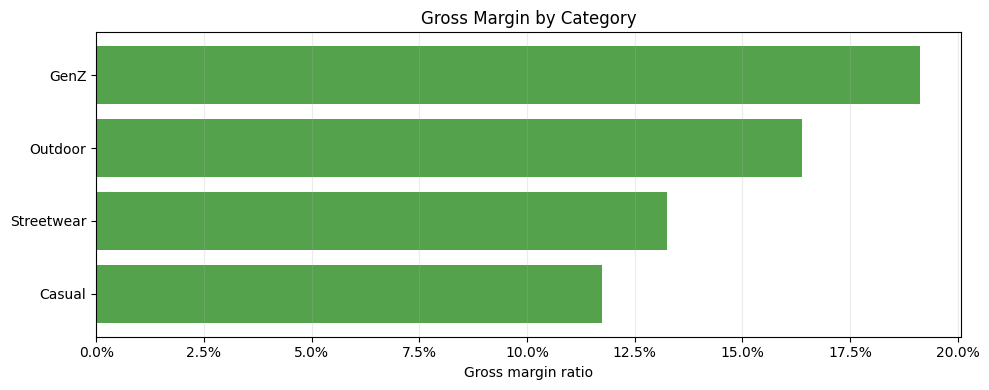

In [6]:
def summarize_financials(df, group_col):
    agg = df.groupby(group_col, dropna=False).agg(
        total_revenue=("revenue", "sum"),
        number_of_items=("revenue", "size"),
        total_quantity=("quantity", "sum"),
        average_selling_price=("item_price", "mean"),
        average_revenue_per_item=("revenue", "mean"),
    )
    if "order_id" in df.columns:
        agg["number_of_orders"] = df.groupby(group_col, dropna=False)["order_id"].nunique()
    if margin_available:
        margin_agg = df.groupby(group_col, dropna=False).agg(
            total_cogs=("cogs", "sum"),
            gross_profit=("gross_profit", "sum"),
            average_margin_per_order_item=("gross_profit", "mean"),
            average_cogs_per_unit=("cogs", "sum"),
        )
        agg = agg.join(margin_agg)
        agg["average_cogs_per_unit"] = agg["total_cogs"] / agg["total_quantity"].replace(0, np.nan)
        agg["gross_margin_ratio"] = np.where(agg["total_revenue"].abs() < 1e-9, np.nan, agg["gross_profit"] / agg["total_revenue"])
    agg = agg.reset_index().rename(columns={group_col: "group"})
    agg["revenue_rank"] = agg["total_revenue"].rank(ascending=False, method="min")
    if margin_available:
        agg["gross_profit_rank"] = agg["gross_profit"].rank(ascending=False, method="min")
        agg["gross_margin_rank"] = agg["gross_margin_ratio"].rank(ascending=False, method="min")
    return agg.sort_values("total_revenue", ascending=False)


if not analysis_ready:
    print("WARNING: Skipping category financial summary because the financial dataset is not available.")
else:
    category_summary = summarize_financials(financial_items, "category")
    display(category_summary)

    if margin_available:
        high_margin_categories = category_summary.sort_values("gross_margin_ratio", ascending=False).head(5)
        print("Highest-margin categories")
        display(high_margin_categories)
        plot_df = category_summary.sort_values("gross_margin_ratio", ascending=True)
        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
        ax.barh(plot_df["group"].astype(str), plot_df["gross_margin_ratio"], color="#54A24B")
        ax.set_title("Gross Margin by Category")
        ax.set_xlabel("Gross margin ratio")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()
    else:
        print("Gross margin by category cannot be evaluated without COGS/cost fields.")

## 7. Financial summary by segment

Aggregate the same financial metrics by segment when segment data is available. Premium/high-end margin comparison is attempted only when explicit premium-like segment labels exist.

,group,total_revenue,number_of_items,total_quantity,average_selling_price,average_revenue_per_item,number_of_orders,total_cogs,gross_profit,average_margin_per_order_item,average_cogs_per_unit,gross_margin_ratio,revenue_rank,gross_profit_rank,gross_margin_rank
3,Everyday,5.376849e+09,182533,819449,6557.849737,29456.858005,181514,4.615280e+09,7.615685e+08,4172.223680,5632.174983,0.141638,1.0,1.0,4.0
2,Balanced,5.127409e+09,103333,464217,11042.463057,49620.242551,103023,4.469082e+09,6.583266e+08,6370.923309,9627.139689,0.128394,2.0,2.0,5.0
4,Performance,2.390412e+09,96730,435685,5490.614972,24712.209461,96303,2.111335e+09,2.790765e+08,2885.108298,4846.013738,0.116748,3.0,4.0,6.0
0,Activewear,2.047815e+09,230375,1036857,1974.924070,8889.051434,171011,1.684365e+09,3.634498e+08,1577.644270,1624.491541,0.177482,4.0,3.0,2.0
5,Premium,4.801314e+08,31032,139465,3437.840133,15472.138064,30944,4.276257e+08,5.250571e+07,1691.986143,3066.186315,0.109357,5.0,6.0,7.0
1,All-weather,4.275845e+08,22570,101147,4236.687432,18944.817234,22553,3.809160e+08,4.666849e+07,2067.722264,3765.964719,0.109144,6.0,7.0,8.0
7,Trendy,3.435991e+08,37159,166848,2060.453326,9246.726106,37054,2.778738e+08,6.572530e+07,1768.758503,1665.430800,0.191285,7.0,5.0,1.0
6,Standard,2.366771e+08,10937,49475,4780.642249,21640.042580,10924,1.969720e+08,3.970512e+07,3630.348004,3981.243650,0.167761,8.0,8.0,3.0


Premium/high-end labeled segments appear lower on average gross margin: 10.94% vs 14.75% for other segments.


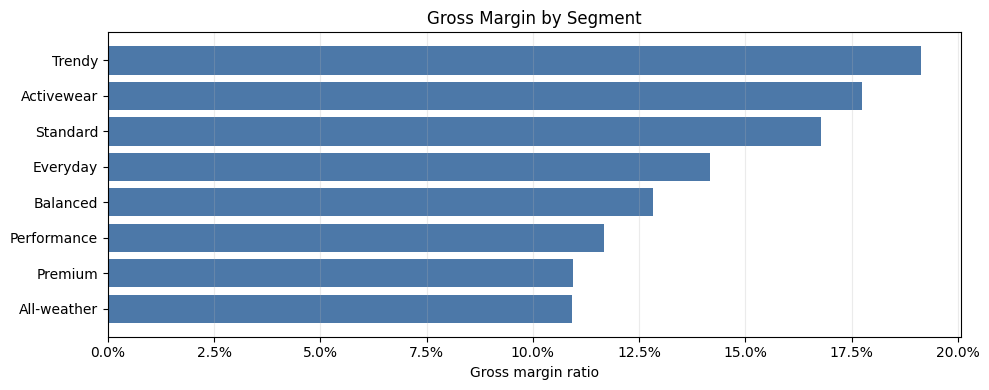

In [7]:
def is_premium_label(label):
    label_norm = normalize_name(label)
    return any(term in label_norm for term in ["premium", "luxury", "high_end", "highend", "elite", "pro", "prestige", "upper"])


if not analysis_ready:
    print("WARNING: Skipping segment financial summary because the financial dataset is not available.")
elif financial_items["segment"].nunique(dropna=True) <= 1 and financial_items["segment"].dropna().astype(str).iloc[0] == "Unknown":
    print("Segment data is unavailable; segment-specific margin analysis is skipped.")
else:
    segment_summary = summarize_financials(financial_items, "segment")
    display(segment_summary)
    if margin_available:
        segment_summary["is_premium_or_high_end_label"] = segment_summary["group"].astype(str).map(is_premium_label)
        premium_available = bool(segment_summary["is_premium_or_high_end_label"].any())
        if premium_available:
            premium_margin = segment_summary.loc[segment_summary["is_premium_or_high_end_label"], "gross_margin_ratio"].mean()
            other_margin = segment_summary.loc[~segment_summary["is_premium_or_high_end_label"], "gross_margin_ratio"].mean()
            direction = "higher" if premium_margin > other_margin else "lower" if premium_margin < other_margin else "similar"
            premium_margin_statement = f"Premium/high-end labeled segments appear {direction} on average gross margin: {premium_margin:.2%} vs {other_margin:.2%} for other segments."
        else:
            top_margin_segment = segment_summary.sort_values("gross_margin_ratio", ascending=False).iloc[0]
            premium_margin_statement = f"No explicit premium/high-end label was detected. Highest-margin segment is {top_margin_segment['group']} at {top_margin_segment['gross_margin_ratio']:.2%}."
        print(premium_margin_statement)

        plot_df = segment_summary.sort_values("gross_margin_ratio", ascending=True)
        fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
        ax.barh(plot_df["group"].astype(str), plot_df["gross_margin_ratio"], color="#4C78A8")
        ax.set_title("Gross Margin by Segment")
        ax.set_xlabel("Gross margin ratio")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()
    else:
        print("Gross margin by segment cannot be evaluated without COGS/cost fields.")

## 8. Revenue versus gross margin relationship

Compare revenue scale against gross margin ratio by category and segment. This identifies high-revenue/high-margin groups, high-revenue/low-margin groups, and smaller high-margin opportunities without implying causality.

Revenue versus category gross margin correlation is -0.361; revenue versus segment gross margin correlation is -0.161.


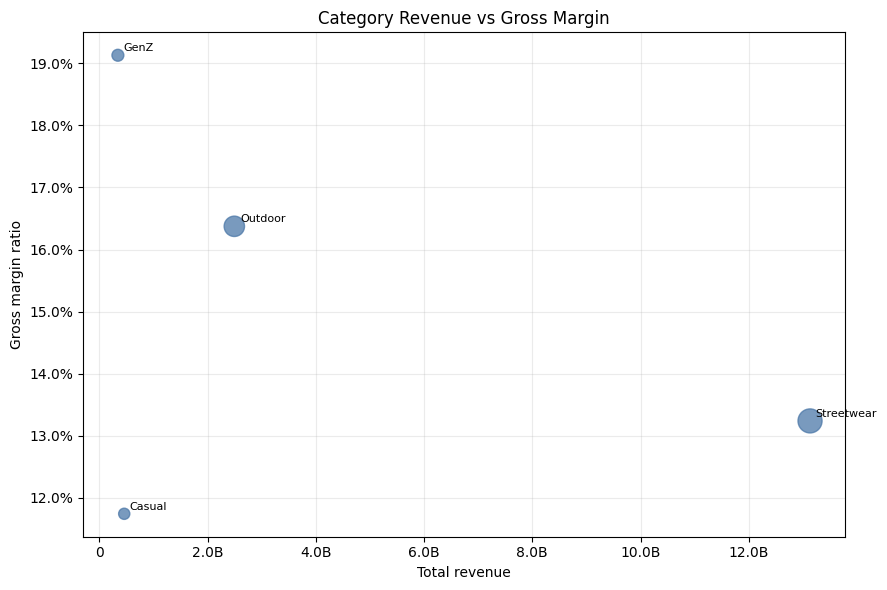

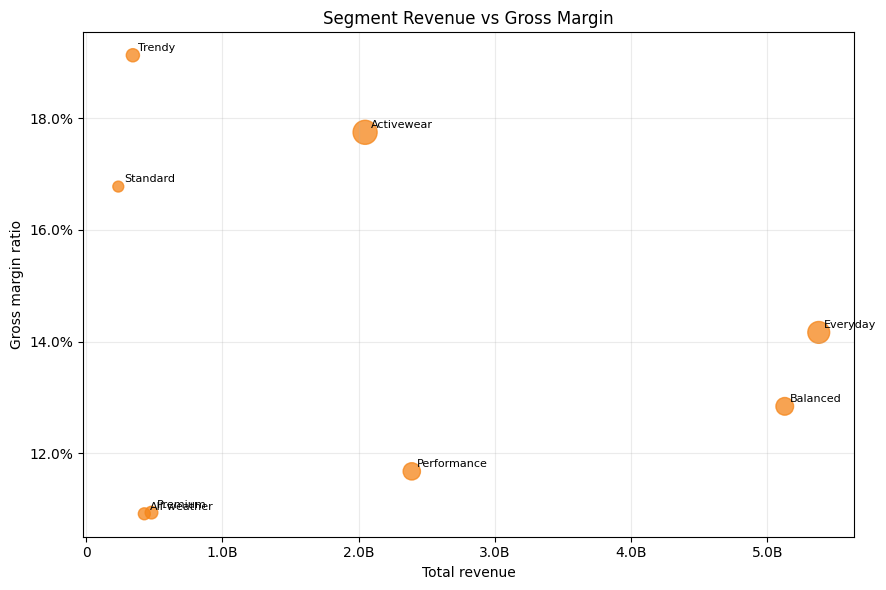

In [8]:
if not analysis_ready or not margin_available:
    print("WARNING: Skipping revenue versus margin relationship because gross margin is not available.")
else:
    category_corr = category_summary["total_revenue"].corr(category_summary["gross_margin_ratio"]) if len(category_summary) >= 3 else np.nan
    segment_corr = segment_summary["total_revenue"].corr(segment_summary["gross_margin_ratio"]) if isinstance(segment_summary, pd.DataFrame) and len(segment_summary) >= 3 and "gross_margin_ratio" in segment_summary else np.nan
    revenue_margin_statement = f"Revenue versus category gross margin correlation is {category_corr:.3f}; revenue versus segment gross margin correlation is {segment_corr:.3f}."
    print(revenue_margin_statement)

    fig, ax = plt.subplots(figsize=(9, 6))
    size_values = category_summary["total_quantity"].fillna(category_summary["number_of_items"]).clip(lower=1)
    size_scaled = 50 + 250 * (size_values / size_values.max())
    ax.scatter(category_summary["total_revenue"], category_summary["gross_margin_ratio"], s=size_scaled, color="#4C78A8", alpha=0.75)
    for row in category_summary.itertuples():
        ax.annotate(str(row.group), (row.total_revenue, row.gross_margin_ratio), fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.set_title("Category Revenue vs Gross Margin")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Gross margin ratio")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    if isinstance(segment_summary, pd.DataFrame) and not segment_summary.empty and "gross_margin_ratio" in segment_summary:
        fig, ax = plt.subplots(figsize=(9, 6))
        size_values = segment_summary["total_quantity"].fillna(segment_summary["number_of_items"]).clip(lower=1)
        size_scaled = 50 + 250 * (size_values / size_values.max())
        ax.scatter(segment_summary["total_revenue"], segment_summary["gross_margin_ratio"], s=size_scaled, color="#F58518", alpha=0.75)
        for row in segment_summary.itertuples():
            ax.annotate(str(row.group), (row.total_revenue, row.gross_margin_ratio), fontsize=8, xytext=(4, 3), textcoords="offset points")
        ax.set_title("Segment Revenue vs Gross Margin")
        ax.set_xlabel("Total revenue")
        ax.set_ylabel("Gross margin ratio")
        ax.xaxis.set_major_formatter(currency_axis)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

## 9. Category revenue vs margin matrix

Use median category revenue and median category margin as thresholds for a 2x2 matrix: core profit drivers, volume-driven low-margin groups, niche high-margin opportunities, and lower-priority groups.

,quadrant,categories,category_count,revenue,gross_profit,avg_margin
1,high_revenue_low_margin,Streetwear,1,1.313135e+10,1.738677e+09,0.132407
0,high_revenue_high_margin,Outdoor,1,2.494883e+09,4.085200e+08,0.163743
3,low_revenue_low_margin,Casual,1,4.606484e+08,5.410395e+07,0.117452
2,low_revenue_high_margin,GenZ,1,3.435991e+08,6.572530e+07,0.191285


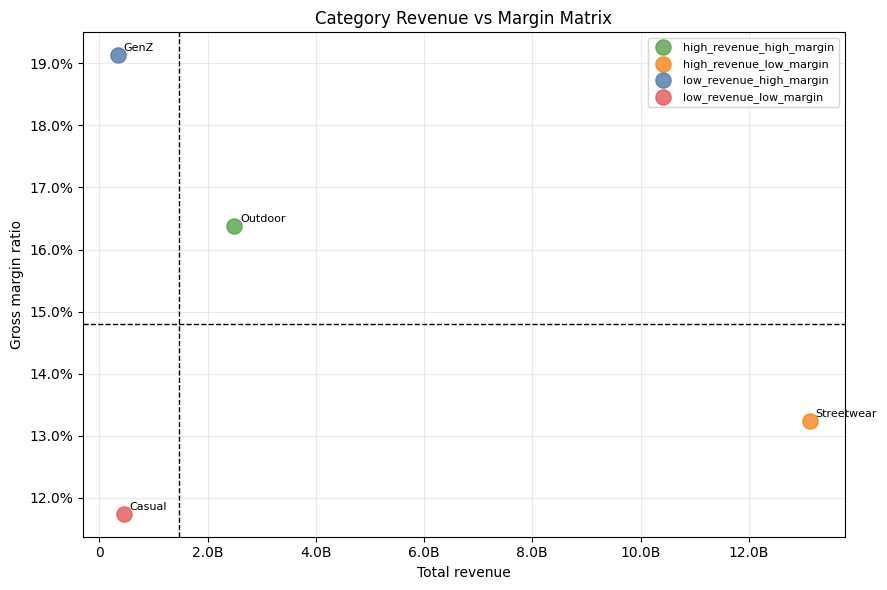

In [9]:
if not analysis_ready or not margin_available:
    print("WARNING: Skipping category revenue vs margin matrix because gross margin is not available.")
else:
    revenue_threshold = category_summary["total_revenue"].median()
    margin_threshold = category_summary["gross_margin_ratio"].median()
    quadrant_df = category_summary.copy()
    quadrant_df["revenue_level"] = np.where(quadrant_df["total_revenue"] >= revenue_threshold, "high_revenue", "low_revenue")
    quadrant_df["margin_level"] = np.where(quadrant_df["gross_margin_ratio"] >= margin_threshold, "high_margin", "low_margin")
    quadrant_df["quadrant"] = quadrant_df["revenue_level"] + "_" + quadrant_df["margin_level"]

    quadrant_summary = (
        quadrant_df.groupby("quadrant", as_index=False)
        .agg(
            categories=("group", lambda values: ", ".join(map(str, values))),
            category_count=("group", "size"),
            revenue=("total_revenue", "sum"),
            gross_profit=("gross_profit", "sum"),
            avg_margin=("gross_margin_ratio", "mean"),
        )
        .sort_values("revenue", ascending=False)
    )
    display(quadrant_summary)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = {
        "high_revenue_high_margin": "#54A24B",
        "high_revenue_low_margin": "#F58518",
        "low_revenue_high_margin": "#4C78A8",
        "low_revenue_low_margin": "#E45756",
    }
    for quadrant, group in quadrant_df.groupby("quadrant"):
        ax.scatter(group["total_revenue"], group["gross_margin_ratio"], label=quadrant, color=colors.get(quadrant, "#9D9D9D"), s=120, alpha=0.8)
        for row in group.itertuples():
            ax.annotate(str(row.group), (row.total_revenue, row.gross_margin_ratio), fontsize=8, xytext=(4, 3), textcoords="offset points")
    ax.axvline(revenue_threshold, color="black", linestyle="--", linewidth=1)
    ax.axhline(margin_threshold, color="black", linestyle="--", linewidth=1)
    ax.set_title("Category Revenue vs Margin Matrix")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Gross margin ratio")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Price, COGS, and margin distribution checks

Inspect price, COGS, and margin distributions and flag suspicious values such as zero price, negative revenue, negative COGS, margin below 0, margin above 1, and extreme outliers.

,count,mean,std,min,1%,5%,50%,95%,99%,max
item_price,714669.0,5114.690157,3774.817912,392.570000,627.870000,775.540000,4257.770000,11912.290000,15778.481200,43056.000000
product_price,714669.0,5508.186543,3989.319352,440.370000,699.720957,811.886514,4487.591719,12606.228520,16696.350000,40950.000000
revenue,714669.0,22990.330608,22352.458071,442.890000,892.414800,2050.140000,15442.120000,70797.336000,95806.373200,331570.400000
cogs,714669.0,19818.196283,19987.239122,346.308669,700.874382,1725.139189,13013.784000,62815.222494,87716.006045,311220.000000
gross_profit,714669.0,3172.134326,6983.285489,-75557.121208,-13253.259518,-3447.006672,1475.215285,15852.452153,29205.718215,80311.606561
gross_margin_ratio,714669.0,0.133773,0.219585,-1.037056,-0.838549,-0.175211,0.126711,0.440712,0.486766,0.527602


,check,count
0,zero_or_negative_item_price,0
1,negative_revenue,0
2,zero_revenue,0
3,negative_cogs,0
4,negative_margin_ratio,133052
5,margin_ratio_above_1,0
6,extreme_margin_iqr_outliers,15610


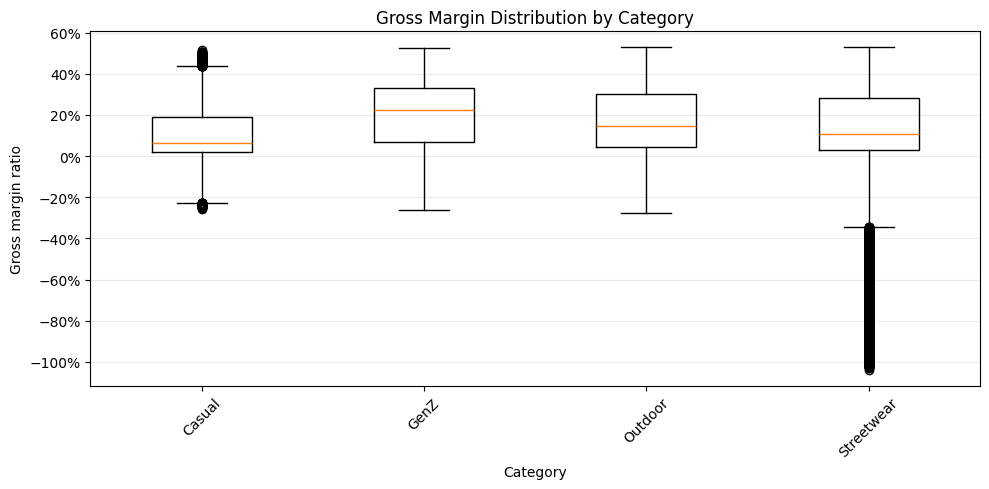

In [10]:
if not analysis_ready:
    print("WARNING: Skipping distribution checks because the financial dataset is not available.")
else:
    summary_cols = ["item_price", "product_price", "revenue", "cogs", "gross_profit", "gross_margin_ratio"]
    available_summary_cols = [col for col in summary_cols if col in financial_items.columns and financial_items[col].notna().any()]
    distribution_summary = financial_items[available_summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
    display(distribution_summary)

    suspicious_rows = []
    suspicious_rows.append({"check": "zero_or_negative_item_price", "count": int((financial_items["item_price"].fillna(np.nan) <= 0).sum()) if "item_price" in financial_items else np.nan})
    suspicious_rows.append({"check": "negative_revenue", "count": int((financial_items["revenue"] < 0).sum())})
    suspicious_rows.append({"check": "zero_revenue", "count": int((financial_items["revenue"] == 0).sum())})
    if margin_available:
        suspicious_rows.append({"check": "negative_cogs", "count": int((financial_items["cogs"] < 0).sum())})
        suspicious_rows.append({"check": "negative_margin_ratio", "count": int((financial_items["gross_margin_ratio"] < 0).sum())})
        suspicious_rows.append({"check": "margin_ratio_above_1", "count": int((financial_items["gross_margin_ratio"] > 1).sum())})
        q1 = financial_items["gross_margin_ratio"].quantile(0.25)
        q3 = financial_items["gross_margin_ratio"].quantile(0.75)
        iqr = q3 - q1
        suspicious_rows.append({"check": "extreme_margin_iqr_outliers", "count": int(((financial_items["gross_margin_ratio"] < q1 - 1.5 * iqr) | (financial_items["gross_margin_ratio"] > q3 + 1.5 * iqr)).sum())})
    distribution_checks_df = pd.DataFrame(suspicious_rows)
    display(distribution_checks_df)

    if margin_available:
        group_col = "category" if financial_items["category"].nunique() > 1 else "segment"
        labels = []
        values = []
        for name, group in financial_items.groupby(group_col):
            vals = group["gross_margin_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
            if len(vals):
                labels.append(str(name))
                values.append(vals.values)
        if values:
            fig, ax = plt.subplots(figsize=(max(10, len(values) * 0.8), 5))
            ax.boxplot(values, tick_labels=labels, showfliers=True)
            ax.set_title(f"Gross Margin Distribution by {group_col.title()}")
            ax.set_xlabel(group_col.title())
            ax.set_ylabel("Gross margin ratio")
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
            ax.tick_params(axis="x", rotation=45)
            ax.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()

## 11. Monthly margin trend, if date is available

Use `sales.csv` daily Revenue/COGS when available for total margin trend; otherwise use the joined item-level data when order dates are available.

,month,revenue,cogs,gross_profit,gross_margin_ratio
0,2012-07-01,1.304068e+08,1.025165e+08,27890299.64,0.213872
1,2012-08-01,1.590892e+08,1.255853e+08,33503933.88,0.210598
2,2012-09-01,1.293071e+08,1.025962e+08,26710979.00,0.206570
3,2012-10-01,1.101857e+08,8.805481e+07,22130889.42,0.200851
4,2012-11-01,9.818630e+07,7.782008e+07,20366217.83,0.207424
5,2012-12-01,1.143226e+08,9.088911e+07,23433504.44,0.204977
6,2013-01-01,9.130868e+07,7.302380e+07,18284872.95,0.200253
7,2013-02-01,1.097831e+08,9.028688e+07,19496261.35,0.177589
8,2013-03-01,1.518347e+08,1.298978e+08,21936874.84,0.144479
9,2013-04-01,1.989269e+08,1.655820e+08,33344970.79,0.167624


Monthly gross margin worsens from first to last month (21.39% to -1.97%).


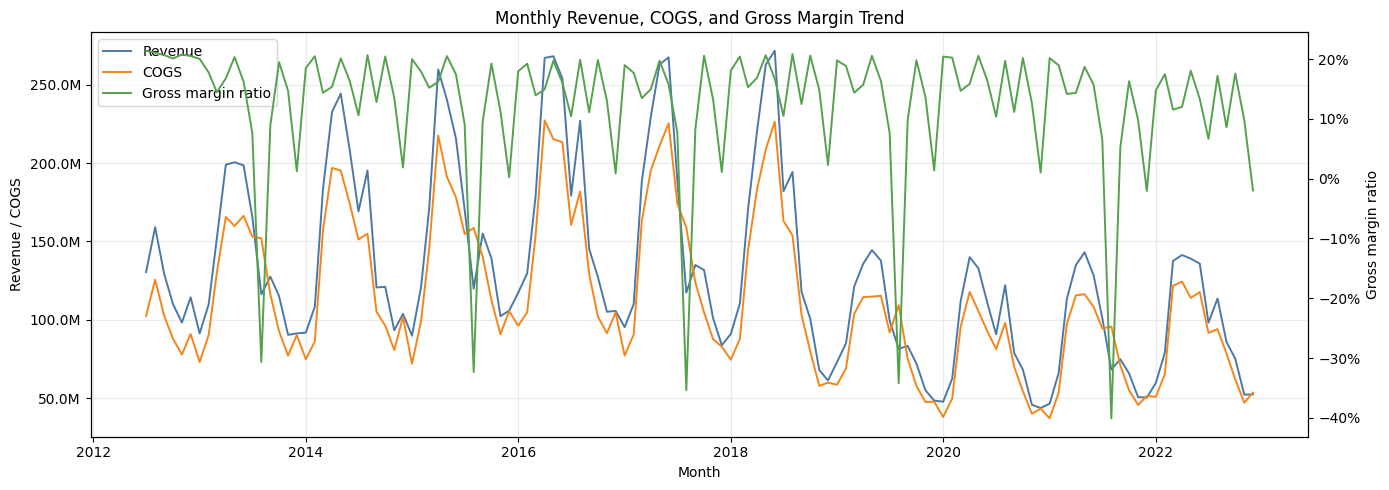

In [11]:
if sales is not None and sales_date_col and sales_revenue_col and sales_cogs_col:
    sales_work = pd.DataFrame({
        "date": parse_datetime_series(sales[sales_date_col]).dt.normalize(),
        "revenue": numeric_series(sales[sales_revenue_col]),
        "cogs": numeric_series(sales[sales_cogs_col]),
    }).dropna(subset=["date", "revenue", "cogs"])
    sales_daily_available = not sales_work.empty
    if sales_daily_available:
        daily_financial = sales_work.groupby("date", as_index=False).agg(revenue=("revenue", "sum"), cogs=("cogs", "sum"))
else:
    sales_daily_available = False

if not sales_daily_available and analysis_ready and date_available and margin_available:
    daily_financial = financial_items.groupby("order_date", as_index=False).agg(revenue=("revenue", "sum"), cogs=("cogs", "sum")).rename(columns={"order_date": "date"})
elif not sales_daily_available:
    daily_financial = pd.DataFrame()

if daily_financial.empty:
    print("Monthly margin trend cannot be evaluated because no dated revenue/COGS data is available.")
else:
    daily_financial["gross_profit"] = daily_financial["revenue"] - daily_financial["cogs"]
    daily_financial["gross_margin_ratio"] = np.where(daily_financial["revenue"].abs() < 1e-9, np.nan, daily_financial["gross_profit"] / daily_financial["revenue"])
    daily_financial["month"] = daily_financial["date"].dt.to_period("M").dt.to_timestamp()
    monthly_financial = daily_financial.groupby("month", as_index=False).agg(revenue=("revenue", "sum"), cogs=("cogs", "sum"), gross_profit=("gross_profit", "sum"))
    monthly_financial["gross_margin_ratio"] = np.where(monthly_financial["revenue"].abs() < 1e-9, np.nan, monthly_financial["gross_profit"] / monthly_financial["revenue"])
    first_margin = monthly_financial["gross_margin_ratio"].dropna().iloc[0] if monthly_financial["gross_margin_ratio"].notna().any() else np.nan
    last_margin = monthly_financial["gross_margin_ratio"].dropna().iloc[-1] if monthly_financial["gross_margin_ratio"].notna().any() else np.nan
    margin_change = last_margin - first_margin if pd.notna(first_margin) and pd.notna(last_margin) else np.nan
    if pd.notna(margin_change):
        if abs(margin_change) < 0.01:
            margin_trend_statement = f"Monthly gross margin appears broadly stable from first to last month ({first_margin:.2%} to {last_margin:.2%})."
        elif margin_change > 0:
            margin_trend_statement = f"Monthly gross margin improves from first to last month ({first_margin:.2%} to {last_margin:.2%})."
        else:
            margin_trend_statement = f"Monthly gross margin worsens from first to last month ({first_margin:.2%} to {last_margin:.2%})."
    display(monthly_financial.head(20))
    print(margin_trend_statement)

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly_financial["month"], monthly_financial["revenue"], label="Revenue", color="#4C78A8", linewidth=1.4)
    ax1.plot(monthly_financial["month"], monthly_financial["cogs"], label="COGS", color="#F58518", linewidth=1.4)
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Revenue / COGS")
    ax1.yaxis.set_major_formatter(currency_axis)
    ax2 = ax1.twinx()
    ax2.plot(monthly_financial["month"], monthly_financial["gross_margin_ratio"], label="Gross margin ratio", color="#54A24B", linewidth=1.4)
    ax2.set_ylabel("Gross margin ratio")
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    ax1.set_title("Monthly Revenue, COGS, and Gross Margin Trend")
    ax1.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 12. Leakage-safe COGS and margin forecast feature preview

Create historical COGS and margin feature examples. Values are shifted before rolling calculations so the feature for date `t` uses only values available before `t`.

In [12]:
if 'daily_financial' not in globals() or daily_financial.empty:
    print("WARNING: Skipping leakage-safe feature preview because no dated revenue/COGS data is available.")
else:
    feature_df = daily_financial.sort_values("date").copy()
    feature_df["gross_profit"] = feature_df["revenue"] - feature_df["cogs"]
    feature_df["gross_margin_ratio"] = np.where(feature_df["revenue"].abs() < 1e-9, np.nan, feature_df["gross_profit"] / feature_df["revenue"])
    feature_df["historical_margin_lag"] = feature_df["gross_margin_ratio"].shift(1)
    feature_df["cogs_lag"] = feature_df["cogs"].shift(1)
    feature_df["gross_profit_lag"] = feature_df["gross_profit"].shift(1)
    feature_df["margin_ratio_lag"] = feature_df["gross_margin_ratio"].shift(1)
    shifted_cogs = feature_df["cogs"].shift(1)
    shifted_margin = feature_df["gross_margin_ratio"].shift(1)
    feature_df["cogs_roll_mean"] = shifted_cogs.rolling(window=30, min_periods=7).mean()
    feature_df["margin_ratio_roll_mean"] = shifted_margin.rolling(window=30, min_periods=7).mean()

    feature_preview = feature_df[[
        "date", "revenue", "cogs", "gross_profit", "gross_margin_ratio",
        "historical_margin_lag", "cogs_lag", "cogs_roll_mean", "margin_ratio_lag",
        "margin_ratio_roll_mean", "gross_profit_lag",
    ]].dropna(subset=["historical_margin_lag", "cogs_lag"], how="all").head(20)
    if feature_preview.empty:
        feature_preview = feature_df.head(20)
    display(feature_preview)
    print("Leakage-safe construction: COGS, gross profit, and margin are shifted before rolling feature calculations.")
    print(forecast_feature_warning)
    print("Recommended COGS/margin forecast features:", ", ".join(recommended_margin_features))

,date,revenue,cogs,gross_profit,gross_margin_ratio,historical_margin_lag,cogs_lag,cogs_roll_mean,margin_ratio_lag,margin_ratio_roll_mean,gross_profit_lag
1,2012-07-05,2751773.45,2150580.23,601193.22,0.218475,0.222611,3982991.19,NaN,0.222611,NaN,1140556.75
2,2012-07-06,3054029.42,2517632.84,536396.58,0.175636,0.218475,2150580.23,NaN,0.218475,NaN,601193.22
3,2012-07-07,2667930.94,2108246.62,559684.32,0.209782,0.175636,2517632.84,NaN,0.175636,NaN,536396.58
4,2012-07-08,2360851.90,1808622.79,552229.11,0.233911,0.209782,2108246.62,NaN,0.209782,NaN,559684.32
5,2012-07-09,3548386.46,2787841.68,760544.78,0.214335,0.233911,1808622.79,NaN,0.233911,NaN,552229.11
6,2012-07-10,5234938.62,4044438.84,1190499.78,0.227414,0.214335,2787841.68,NaN,0.214335,NaN,760544.78
7,2012-07-11,5582884.78,4338313.07,1244571.71,0.222926,0.227414,4044438.84,2.771479e+06,0.227414,0.214595,1190499.78
8,2012-07-12,5734632.02,4458811.27,1275820.75,0.222476,0.222926,4338313.07,2.967333e+06,0.222926,0.215636,1244571.71
9,2012-07-13,5309511.71,4143402.78,1166108.93,0.219626,0.222476,4458811.27,3.133053e+06,0.222476,0.216396,1275820.75
10,2012-07-14,3820831.41,3075464.87,745366.54,0.195080,0.219626,4143402.78,3.234088e+06,0.219626,0.216719,1166108.93


Leakage-safe construction: COGS, gross profit, and margin are shifted before rolling feature calculations.
Future COGS, future margin, and future product mix must not be used directly for forecasting unless separately forecasted.
Recommended COGS/margin forecast features: historical_margin_lag, cogs_lag, cogs_roll_mean, margin_ratio_lag, margin_ratio_roll_mean, gross_profit_lag


## 13. Key observations and warnings

Summarize highest-margin groups, revenue/profit alignment, suspicious values, margin trend, and leakage-safe feature recommendations.

In [13]:
if analysis_ready:
    if margin_available and not category_summary.empty:
        highest_margin_categories = ", ".join(
            f"{row.group} ({row.gross_margin_ratio:.1%})"
            for row in category_summary.sort_values("gross_margin_ratio", ascending=False).head(3).itertuples()
        )
        high_rev_low_margin = quadrant_df.loc[quadrant_df["quadrant"] == "high_revenue_low_margin", "group"].astype(str).tolist() if not quadrant_df.empty else []
        low_rev_high_margin = quadrant_df.loc[quadrant_df["quadrant"] == "low_revenue_high_margin", "group"].astype(str).tolist() if not quadrant_df.empty else []
        high_rev_low_margin_text = ", ".join(high_rev_low_margin) if high_rev_low_margin else "None flagged"
        low_rev_high_margin_text = ", ".join(low_rev_high_margin) if low_rev_high_margin else "None flagged"
    else:
        highest_margin_categories = "Not available"
        high_rev_low_margin_text = "Not available"
        low_rev_high_margin_text = "Not available"

    if margin_available and isinstance(segment_summary, pd.DataFrame) and not segment_summary.empty and "gross_margin_ratio" in segment_summary:
        highest_margin_segments = ", ".join(
            f"{row.group} ({row.gross_margin_ratio:.1%})"
            for row in segment_summary.sort_values("gross_margin_ratio", ascending=False).head(3).itertuples()
        )
    else:
        highest_margin_segments = "Not available"

    suspicious_text = (
        "; ".join(f"{row.check}: {int(row.count)}" for row in distribution_checks_df.itertuples() if pd.notna(row.count))
        if not distribution_checks_df.empty else "No checks available"
    )

    print("Insight summary")
    print(f"- Highest-margin categories: {highest_margin_categories}")
    print(f"- Highest-margin segments: {highest_margin_segments}")
    print(f"- High-revenue but low-margin groups: {high_rev_low_margin_text}")
    print(f"- Low-revenue but high-margin groups: {low_rev_high_margin_text}")
    print(f"- Revenue alignment with profit/margin: {revenue_margin_statement}")
    print(f"- Suspicious price, COGS, or margin values: {suspicious_text}")
    print(f"- Margin change over time: {margin_trend_statement}")
    print(f"- Recommended leakage-safe COGS and margin forecast features: {', '.join(recommended_margin_features)}")
    print(f"- Forecasting warning: {forecast_feature_warning}")
else:
    print("Insight summary")
    print("- Price, COGS, and gross margin analysis could not be completed because required financial fields were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Highest-margin categories: GenZ (19.1%), Outdoor (16.4%), Streetwear (13.2%)
- Highest-margin segments: Trendy (19.1%), Activewear (17.7%), Standard (16.8%)
- High-revenue but low-margin groups: Streetwear
- Low-revenue but high-margin groups: GenZ
- Revenue alignment with profit/margin: Revenue versus category gross margin correlation is -0.361; revenue versus segment gross margin correlation is -0.161.
- Suspicious price, COGS, or margin values: zero_or_negative_item_price: 0; negative_revenue: 0; zero_revenue: 0; negative_cogs: 0; negative_margin_ratio: 133052; margin_ratio_above_1: 0; extreme_margin_iqr_outliers: 15610
- Margin change over time: Monthly gross margin worsens from first to last month (21.39% to -1.97%).
- Recommended leakage-safe COGS and margin forecast features: historical_margin_lag, cogs_lag, cogs_roll_mean, margin_ratio_lag, margin_ratio_roll_mean, gross_profit_lag
- Forecasting warning: Future COGS, future margin, and future product mix must n